In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 


In [2]:
# dataset using 
deliveris=pd.read_csv('deliveries.csv') # dataset of all the ball of the ipl 
matches=pd.read_csv('matches.csv')      # dataset of the matches record in the ipl 
matches.columns

Index(['id', 'Season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='str')

# this project is to make a ml model which predict the win-rate of the teams in ipl match 

solution - to predict wheter a team will win or not we have to get the target they are chasing their current run rate , their required run rate , wickets in-hand , batsmen on field , teams that are playing 

In [3]:
df=deliveris.groupby(['match_id','inning']).sum()['total_runs'].reset_index()
df=df[df['inning']==1]
df=df.merge(matches,left_on='match_id',right_on='id')
df.columns

Index(['match_id', 'inning', 'total_runs', 'id', 'Season', 'city', 'date',
       'team1', 'team2', 'toss_winner', 'toss_decision', 'result',
       'dl_applied', 'winner', 'win_by_runs', 'win_by_wickets',
       'player_of_match', 'venue', 'umpire1', 'umpire2', 'umpire3'],
      dtype='str')

In [ ]:
#df.drop(columns=['umpire1','umpire2','umpire3'],inplace=True)
df_c=df.copy()

In [5]:
# renaming old teams name into current 
df_c['team1']=df['team1'].replace({'Delhi Daredevils':'Delhi Capitals', 'Deccan Chargers':'Sunrisers Hyderabad',})
df_c['team2']=df['team2'].replace({'Delhi Daredevils':'Delhi Capitals', 'Deccan Chargers':'Sunrisers Hyderabad',})

In [ ]:
# removing teams which now not exist 
team=['Sunrisers Hyderabad',           
'Mumbai Indians',                
'Kings XI Punjab',                
'Chennai Super Kings',          
'Royal Challengers Bangalore',   
'Kolkata Knight Riders',        
'Delhi Capitals',             
'Rajasthan Royals',]
#df_c=df_c[df_c['team1'].isin(team)]
#df_c=df_c[df_c['team2'].isin(team)]
#<--------------------------------------->

# we do not want the data which have rain or dl applied
#df_c=df_c[df_c['dl_applied']==0]

df_c=df_c[['match_id', 'total_runs','winner','city']]

In [7]:
# merging with deliveris 
df_final=deliveris.merge(df_c,on='match_id')
df_f=df_final.copy()


In [8]:
# runs left to chase
df_f['current_score']=df_f[df_f['inning']==2].groupby('match_id')['total_runs_x'].cumsum()
df_f['run_left']=df_f['total_runs_y']+1-df_f['current_score']


In [9]:
# balls left 
df_f['ball_left']=126-(df_f['over']*6+df_f['ball'])


In [ ]:
# wickets_left
#df_f['player_dismissed']=df_f['player_dismissed'].fillna('0')
#df_f['player_dismissed']=df_f['player_dismissed'].apply(lambda x: x if x=='0' else '1')
df_f['player_dismissed']=df_f['player_dismissed'].astype('int')
df_f['wickets_left']=10-df_f[df_f['inning']==2].groupby('match_id')['player_dismissed'].cumsum()


In [11]:
# current run rate 
df_f['crr']=df_f['current_score']*6/(120-df_f['ball_left'])

# required run rate

df_f['rrr']=(df_f['run_left']*6)/df_f['ball_left']

In [20]:
# adding result

def check(data):
    return 1 if data['winner']==data['batting_team'] else 0

df_f['result']=df_f.apply(check,axis=1)
# <--------------------------------------------------------------------->

# extracting useful columns
train=df_f[df_f['inning']==2][['batting_team','bowling_team','current_score', 'run_left', 
      'ball_left', 'wickets_left', 'crr', 'rrr','total_runs_y','result']]

In [24]:
# final training data 
train=train.sample(train.shape[0])

<------------------------------------->
 EDA on the data 

 1. data have 72,413 sample with 10 features 
 2. only 5 null values in rrr
 3. total_runs mean==median approx to  normal distribution


<Axes: xlabel='total_runs_y', ylabel='Density'>

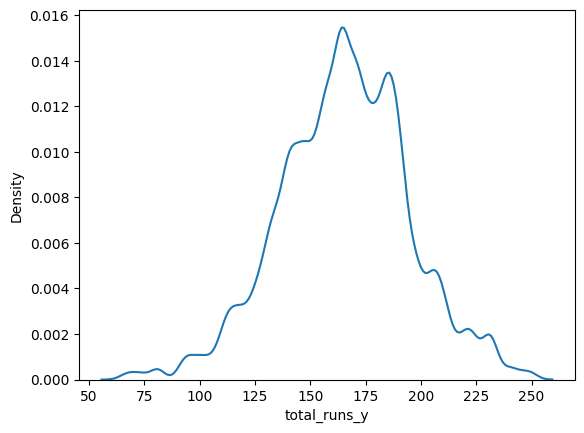

In [34]:
sns.kdeplot(data=train,x='total_runs_y')